# 05. Тематическое моделирование — BigARTM

BigARTM (Big Additive Regularization of Topic Models) — обобщение LDA с аддитивной регуляризацией.
В отличие от LDA, где максимизируется только правдоподобие, BigARTM максимизирует регуляризованный функционал:

$$\mathcal{L}(\Phi, \Theta) = \sum_{d,w} n_{dw} \log \sum_t \pi_{wt} \theta_{td} + \sum_i \tau_i R_i(\Phi, \Theta)$$

Регуляризаторы $R_i$ управляют разреженностью, декорреляцией и сглаживанием тем.

**Важно:** этот ноутбук запускается в отдельном окружении с установленным `bigartm`.

## 1. Импорты и настройка путей

In [1]:
from pathlib import Path
import ast
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm import tqdm

import artm

PROJECT_ROOT = Path(r"C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"
BATCHES_DIR = PROJECT_ROOT / "bigartm_batches"   # BigARTM хранит батчи отдельно

for p in (OUTPUT_DIR, MODELS_DIR, FIGURES_DIR, BATCHES_DIR):
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print("BigARTM version:", artm.version())
print("PROJECT_ROOT:", PROJECT_ROOT)

BigARTM version: 0.9.2
PROJECT_ROOT: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis


## 2. Загрузка предобработанных данных

In [2]:
df = pd.read_csv(OUTPUT_DIR / "clean_corpus.csv")
# В 01_data_preprocessing.ipynb токены сохранены как строка через пробел: "слово1 слово2 ..."
df["tokens"] = df["tokens"].apply(lambda x: x.split() if isinstance(x, str) else x)
df["text_for_models"] = df["tokens"].apply(lambda x: " ".join(x) if isinstance(x, list) else x)

texts = df["tokens"].tolist()

print(f"Документов: {len(df)}")
print(f"Пример токенов (1-й документ): {texts[0][:15]}")

Документов: 6385
Пример токенов (1-й документ): ['предположение', 'обратимость', 'линейный', 'разностный', 'оператор', 'постоянный', 'коэффициент', 'пусть', 'комплексный', 'банаховы', 'пространство', 'банахово', 'пространство', 'линейный', 'ограниченный']


## 3. Подготовка батчей для BigARTM

In [ ]:
# Сохранение корпуса во временный файл в формате Vowpal Wabbit (один документ — одна строка).
# BigARTM принимает этот формат через data_format='vowpal_wabbit'.

vw_path = OUTPUT_DIR / "corpus_vw.txt"

with vw_path.open("w", encoding="utf-8") as f:
    for doc_tokens in texts:
        if not doc_tokens:
            continue
        # VW-формат: "doc_name | word1 word2 word3 ..."
        line = "doc | " + " ".join(doc_tokens)
        f.write(line + "\n")

print(f"VW-файл сохранён: {vw_path}")

# Создание батчей
batch_vectorizer = artm.BatchVectorizer(
    data_path=str(vw_path),
    data_format="vowpal_wabbit",
    target_folder=str(BATCHES_DIR),
    batch_size=100,
)

print(f"Батчи созданы: {BATCHES_DIR}")

VW-файл сохранён: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/outputs/corpus_vw.txt
Батчи созданы: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/bigartm_batches


In [ ]:
# Словарь для инициализации модели
dictionary = artm.Dictionary()
dictionary.gather(data_path=str(BATCHES_DIR))

# Фильтрация словаря: убираются слова, встречающиеся меньше 3 раз или в >80% документов
dictionary.filter(
    min_df=3,
    max_df_rate=0.80,
)

# Сохранение словаря в текстовый файл и подсчет токенов
dict_txt_path = str(MODELS_DIR / "bigartm_dictionary.txt")
dictionary.save_text(dict_txt_path)
with open(dict_txt_path, encoding="utf-8") as f:
    n_tokens = sum(1 for line in f if not line.startswith("@") and line.strip())
print(f"Токенов в словаре после фильтрации: {n_tokens}")

Токенов в словаре после фильтрации: 28690


## 4. Вспомогательные функции

In [ ]:
def get_topic_words(model: artm.ARTM, num_words: int = 10) -> dict:
    #Возвращает словарь {topic_name: [(word, score), ...]}
    result = {}
    score = model.score_tracker["TopTokensScore"]
    # Берется последний зафиксированный шаг
    last = score.last_tokens
    last_weights = score.last_weights
    for topic in model.topic_names:
        words = last.get(topic, [])
        weights = last_weights.get(topic, [])
        result[topic] = list(zip(words[:num_words], weights[:num_words]))
    return result


def print_topics(model: artm.ARTM, num_words: int = 10) -> None:
    topic_words = get_topic_words(model, num_words)
    for i, (topic, words) in enumerate(topic_words.items()):
        line = " + ".join(f"{w}({s:.3f})" for w, s in words)
        print(f"  Тема {i + 1:02d}: {line}")


def compute_coherence_cv(topic_words: dict, texts: list, top_n: int = 10) -> float:
    #C_v когерентность через gensim CoherenceModel
    from gensim import corpora
    from gensim.models import CoherenceModel

    topic_words_list = [
        [w for w, _ in pairs[:top_n]]
        for pairs in topic_words.values()
        if pairs
    ]
    # Временный словарь из всех токенов
    all_tokens = [t for doc in texts for t in doc]
    tmp_dict = corpora.Dictionary([all_tokens])

    cm = CoherenceModel(
        topics=topic_words_list,
        texts=texts,
        dictionary=tmp_dict,
        coherence="c_v",
    )
    return cm.get_coherence()


print("Вспомогательные функции загружены.")

Вспомогательные функции загружены.


## 5. Подбор числа тем

Обучаем базовую модель (только разреженность) для разного числа тем и оцениваем когерентность.

In [6]:
NUM_TOPICS_RANGE = [5, 10, 15, 20, 25, 30]
NUM_PASSES       = 15          # проходов по корпусу для предварительного поиска
TAU_SPARSE_PHI   = -0.1        # разреженность Φ
TAU_SPARSE_THETA = -0.1        # разреженность Θ

topic_search_results = []

for num_topics in tqdm(NUM_TOPICS_RANGE, desc="Подбор числа тем"):
    model = artm.ARTM(
        num_topics=num_topics,
        dictionary=dictionary,
        cache_theta=True,
        theta_columns_naming="title",
    )
    model.initialize(dictionary=dictionary)

    # Скоры
    model.scores.add(artm.PerplexityScore(name="PerplexityScore", dictionary=dictionary))
    model.scores.add(artm.SparsityPhiScore(name="SparsityPhiScore"))
    model.scores.add(artm.SparsityThetaScore(name="SparsityThetaScore"))
    model.scores.add(artm.TopTokensScore(name="TopTokensScore", num_tokens=15))

    # Регуляризаторы: разреженность Φ и Θ (отрицательный tau = разреженность)
    model.regularizers.add(artm.SmoothSparsePhiRegularizer(name="SparsePhi",   tau=TAU_SPARSE_PHI))
    model.regularizers.add(artm.SmoothSparseThetaRegularizer(name="SparseTheta", tau=TAU_SPARSE_THETA))

    model.fit_offline(
        batch_vectorizer=batch_vectorizer,
        num_collection_passes=NUM_PASSES,
    )

    perplexity   = model.score_tracker["PerplexityScore"].last_value
    sparsity_phi = model.score_tracker["SparsityPhiScore"].last_value
    sparsity_theta = model.score_tracker["SparsityThetaScore"].last_value

    topic_words = get_topic_words(model, num_words=10)
    coherence   = compute_coherence_cv(topic_words, texts)

    topic_search_results.append({
        "num_topics":     num_topics,
        "coherence":      coherence,
        "perplexity":     perplexity,
        "sparsity_phi":   sparsity_phi,
        "sparsity_theta": sparsity_theta,
    })

topics_df = (
    pd.DataFrame(topic_search_results)
    .sort_values("coherence", ascending=False)
    .reset_index(drop=True)
)
topics_df.to_csv(OUTPUT_DIR / "bigartm_topics_search.csv", index=False)

print("\nРезультаты поиска числа тем:")
print(topics_df.to_string(index=False))

Подбор числа тем: 100%|██████████| 6/6 [02:32<00:00, 25.41s/it]


Результаты поиска числа тем:
 num_topics  coherence  perplexity  sparsity_phi  sparsity_theta
         30   0.609340 1211.638428      0.860887        0.476053
         25   0.599844 1259.935059      0.843649        0.432301
         15   0.569562 1406.447510      0.791365        0.319039
         20   0.569120 1324.630249      0.820319        0.386249
          5   0.554405 1728.286743      0.603723        0.153641
         10   0.546167 1548.697998      0.732951        0.234487


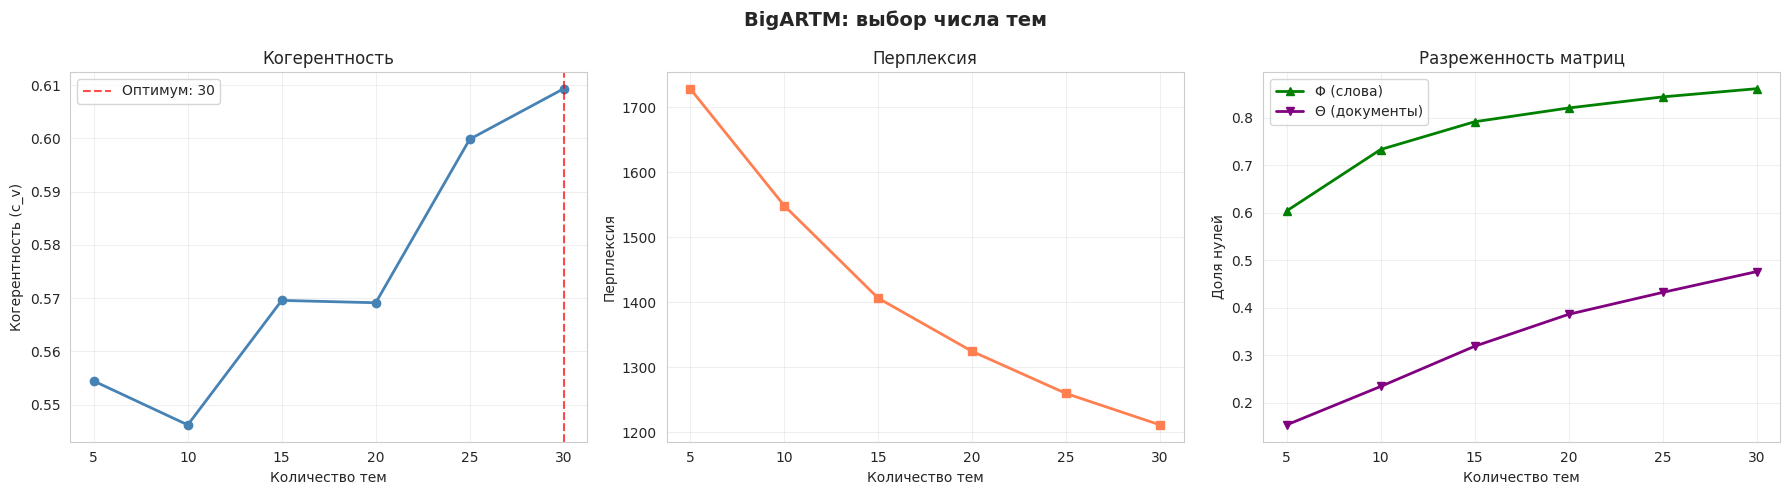

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/bigartm_topics_search.png


In [7]:
plot_df = topics_df.sort_values("num_topics")
best_n  = int(topics_df.iloc[0]["num_topics"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Когерентность
ax = axes[0]
ax.plot(plot_df["num_topics"], plot_df["coherence"],
        marker="o", linewidth=2, color="steelblue")
ax.axvline(best_n, color="red", linestyle="--", alpha=0.7, label=f"Оптимум: {best_n}")
ax.set_xlabel("Количество тем")
ax.set_ylabel("Когерентность (c_v)")
ax.set_title("Когерентность")
ax.legend()
ax.grid(True, alpha=0.3)

# Перплексия
ax = axes[1]
ax.plot(plot_df["num_topics"], plot_df["perplexity"],
        marker="s", linewidth=2, color="coral")
ax.set_xlabel("Количество тем")
ax.set_ylabel("Перплексия")
ax.set_title("Перплексия")
ax.grid(True, alpha=0.3)

# Разреженность
ax = axes[2]
ax.plot(plot_df["num_topics"], plot_df["sparsity_phi"],
        marker="^", linewidth=2, color="green", label="Φ (слова)")
ax.plot(plot_df["num_topics"], plot_df["sparsity_theta"],
        marker="v", linewidth=2, color="purple", label="Θ (документы)")
ax.set_xlabel("Количество тем")
ax.set_ylabel("Доля нулей")
ax.set_title("Разреженность матриц")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("BigARTM: выбор числа тем", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bigartm_topics_search.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bigartm_topics_search.png")

## 6. Подбор коэффициентов регуляризации

Фиксируем лучшее число тем и перебираем τ для регуляризаторов разреженности.

In [ ]:
# Лучшее число тем
BEST_NUM_TOPICS = best_n
print(f"Лучшее число тем: {BEST_NUM_TOPICS}")

# Диапазоны τ для grid search
TAU_SPARSE_PHI_RANGE   = [-0.05, -0.1, -0.2, -0.5]
TAU_SPARSE_THETA_RANGE = [-0.05, -0.1, -0.2, -0.5]
TAU_DECORR_RANGE       = [0.0,   1e5,  1e6        ]
NUM_PASSES_FINAL       = 20

import itertools
param_grid = list(itertools.product(
    TAU_SPARSE_PHI_RANGE,
    TAU_SPARSE_THETA_RANGE,
    TAU_DECORR_RANGE,
))
print(f"Всего комбинаций регуляризаторов: {len(param_grid)}")

Лучшее число тем: 30
Всего комбинаций регуляризаторов: 48


In [9]:
reg_results = []

for tau_phi, tau_theta, tau_decorr in tqdm(param_grid, desc="Подбор регуляризаторов"):
    try:
        model = artm.ARTM(
            num_topics=BEST_NUM_TOPICS,
            dictionary=dictionary,
            cache_theta=True,
            theta_columns_naming="title",
        )
        model.initialize(dictionary=dictionary)

        model.scores.add(artm.PerplexityScore(name="PerplexityScore",    dictionary=dictionary))
        model.scores.add(artm.SparsityPhiScore(name="SparsityPhiScore"))
        model.scores.add(artm.SparsityThetaScore(name="SparsityThetaScore"))
        model.scores.add(artm.TopTokensScore(name="TopTokensScore",       num_tokens=15))

        model.regularizers.add(artm.SmoothSparsePhiRegularizer(name="SparsePhi",     tau=tau_phi))
        model.regularizers.add(artm.SmoothSparseThetaRegularizer(name="SparseTheta", tau=tau_theta))
        if tau_decorr > 0:
            model.regularizers.add(artm.DecorrelatorPhiRegularizer(name="Decorr", tau=tau_decorr))

        model.fit_offline(
            batch_vectorizer=batch_vectorizer,
            num_collection_passes=NUM_PASSES_FINAL,
        )

        perplexity     = model.score_tracker["PerplexityScore"].last_value
        sparsity_phi   = model.score_tracker["SparsityPhiScore"].last_value
        sparsity_theta = model.score_tracker["SparsityThetaScore"].last_value
        topic_words    = get_topic_words(model, num_words=10)
        coherence      = compute_coherence_cv(topic_words, texts)

        reg_results.append({
            "tau_phi":       tau_phi,
            "tau_theta":     tau_theta,
            "tau_decorr":    tau_decorr,
            "coherence":     coherence,
            "perplexity":    perplexity,
            "sparsity_phi":  sparsity_phi,
            "sparsity_theta": sparsity_theta,
        })

    except Exception as e:
        print(f"Ошибка [{tau_phi}, {tau_theta}, {tau_decorr}]: {e}")

reg_df = (
    pd.DataFrame(reg_results)
    .sort_values("coherence", ascending=False)
    .reset_index(drop=True)
)
reg_df.to_csv(OUTPUT_DIR / "bigartm_regularization_search.csv", index=False)

print("\nТоп-10 конфигураций по когерентности:")
print(reg_df.head(10).to_string(index=False))

Подбор регуляризаторов: 100%|██████████| 48/48 [24:53<00:00, 31.11s/it]


Топ-10 конфигураций по когерентности:
 tau_phi  tau_theta  tau_decorr  coherence  perplexity  sparsity_phi  sparsity_theta
   -0.05      -0.20   1000000.0   0.666504 1198.473389      0.864854        0.570650
   -0.05      -0.10   1000000.0   0.662638 1197.609009      0.865550        0.518575
   -0.05      -0.50   1000000.0   0.658866 1202.175415      0.862323        0.640104
   -0.05      -0.05   1000000.0   0.657606 1198.579712      0.865927        0.471574
   -0.10      -0.50   1000000.0   0.655219 1219.447998      0.877747        0.623096
   -0.10      -0.05   1000000.0   0.653871 1218.094604      0.881498        0.470493
   -0.10      -0.20   1000000.0   0.648986 1224.144653      0.879921        0.559196
   -0.10      -0.10   1000000.0   0.648551 1217.474243      0.881057        0.512451
   -0.20      -0.20   1000000.0   0.646360 1247.612183      0.899606        0.538951
   -0.50      -0.50   1000000.0   0.645325 1291.850220      0.932921        0.588405


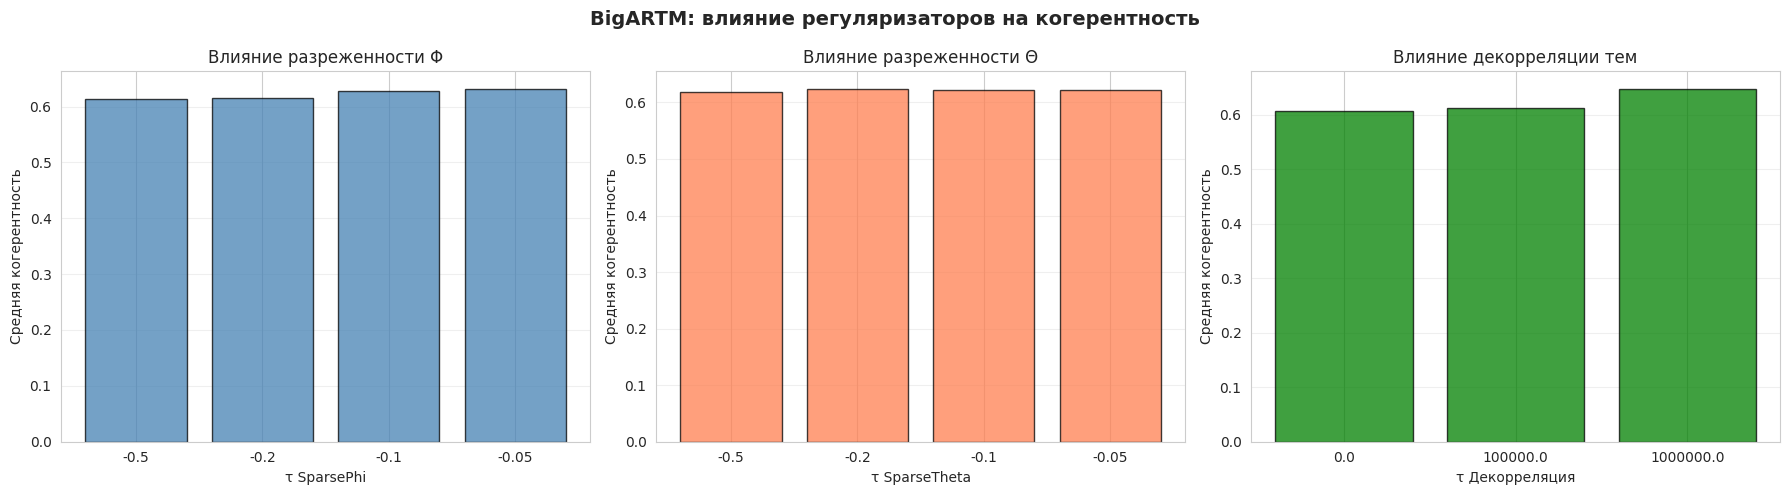

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/bigartm_regularization_search.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Влияние tau_phi
ax = axes[0]
mean_phi = reg_df.groupby("tau_phi")["coherence"].mean().reset_index()
ax.bar(mean_phi["tau_phi"].astype(str), mean_phi["coherence"],
       color="steelblue", alpha=0.75, edgecolor="black")
ax.set_xlabel("τ SparsePhi")
ax.set_ylabel("Средняя когерентность")
ax.set_title("Влияние разреженности Φ")
ax.grid(axis="y", alpha=0.3)

# Влияние tau_theta
ax = axes[1]
mean_theta = reg_df.groupby("tau_theta")["coherence"].mean().reset_index()
ax.bar(mean_theta["tau_theta"].astype(str), mean_theta["coherence"],
       color="coral", alpha=0.75, edgecolor="black")
ax.set_xlabel("τ SparseTheta")
ax.set_ylabel("Средняя когерентность")
ax.set_title("Влияние разреженности Θ")
ax.grid(axis="y", alpha=0.3)

# Влияние декорреляции
ax = axes[2]
mean_decorr = reg_df.groupby("tau_decorr")["coherence"].mean().reset_index()
ax.bar(mean_decorr["tau_decorr"].astype(str), mean_decorr["coherence"],
       color="green", alpha=0.75, edgecolor="black")
ax.set_xlabel("τ Декорреляция")
ax.set_ylabel("Средняя когерентность")
ax.set_title("Влияние декорреляции тем")
ax.grid(axis="y", alpha=0.3)

plt.suptitle("BigARTM: влияние регуляризаторов на когерентность", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bigartm_regularization_search.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bigartm_regularization_search.png")

## 7. Обучение финальной модели

In [11]:
best_reg  = reg_df.iloc[0]
print("Лучшая конфигурация регуляризаторов:")
for k, v in best_reg.items():
    print(f"  {k}: {v}")

FINAL_TAU_PHI   = float(best_reg["tau_phi"])
FINAL_TAU_THETA = float(best_reg["tau_theta"])
FINAL_TAU_DECORR = float(best_reg["tau_decorr"])
NUM_PASSES_FINAL_MODEL = 30

Лучшая конфигурация регуляризаторов:
  tau_phi: -0.05
  tau_theta: -0.2
  tau_decorr: 1000000.0
  coherence: 0.6665036506921694
  perplexity: 1198.473388671875
  sparsity_phi: 0.8648540377616882
  sparsity_theta: 0.5706499814987183


In [12]:
final_model = artm.ARTM(
    num_topics=BEST_NUM_TOPICS,
    dictionary=dictionary,
    cache_theta=True,
    theta_columns_naming="title",
)
final_model.initialize(dictionary=dictionary)

# Скоры
final_model.scores.add(artm.PerplexityScore(name="PerplexityScore",    dictionary=dictionary))
final_model.scores.add(artm.SparsityPhiScore(name="SparsityPhiScore"))
final_model.scores.add(artm.SparsityThetaScore(name="SparsityThetaScore"))
final_model.scores.add(artm.TopTokensScore(name="TopTokensScore",       num_tokens=15))
final_model.scores.add(artm.TopicMassPhiScore(name="TopicMassPhiScore"))

# Регуляризаторы
final_model.regularizers.add(artm.SmoothSparsePhiRegularizer(
    name="SparsePhi", tau=FINAL_TAU_PHI
))
final_model.regularizers.add(artm.SmoothSparseThetaRegularizer(
    name="SparseTheta", tau=FINAL_TAU_THETA
))
if FINAL_TAU_DECORR > 0:
    final_model.regularizers.add(artm.DecorrelatorPhiRegularizer(
        name="Decorr", tau=FINAL_TAU_DECORR
    ))

print(f"Обучение финальной BigARTM модели: {BEST_NUM_TOPICS} тем, {NUM_PASSES_FINAL_MODEL} итераций...")
final_model.fit_offline(
    batch_vectorizer=batch_vectorizer,
    num_collection_passes=NUM_PASSES_FINAL_MODEL,
)

# Сохранение
final_model.save(str(MODELS_DIR / "bigartm_model_best"))
print("Модель сохранена:", MODELS_DIR / "bigartm_model_best")

Обучение финальной BigARTM модели: 30 тем, 30 итераций...
Модель сохранена: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/models/bigartm_model_best


## 8. Динамика обучения

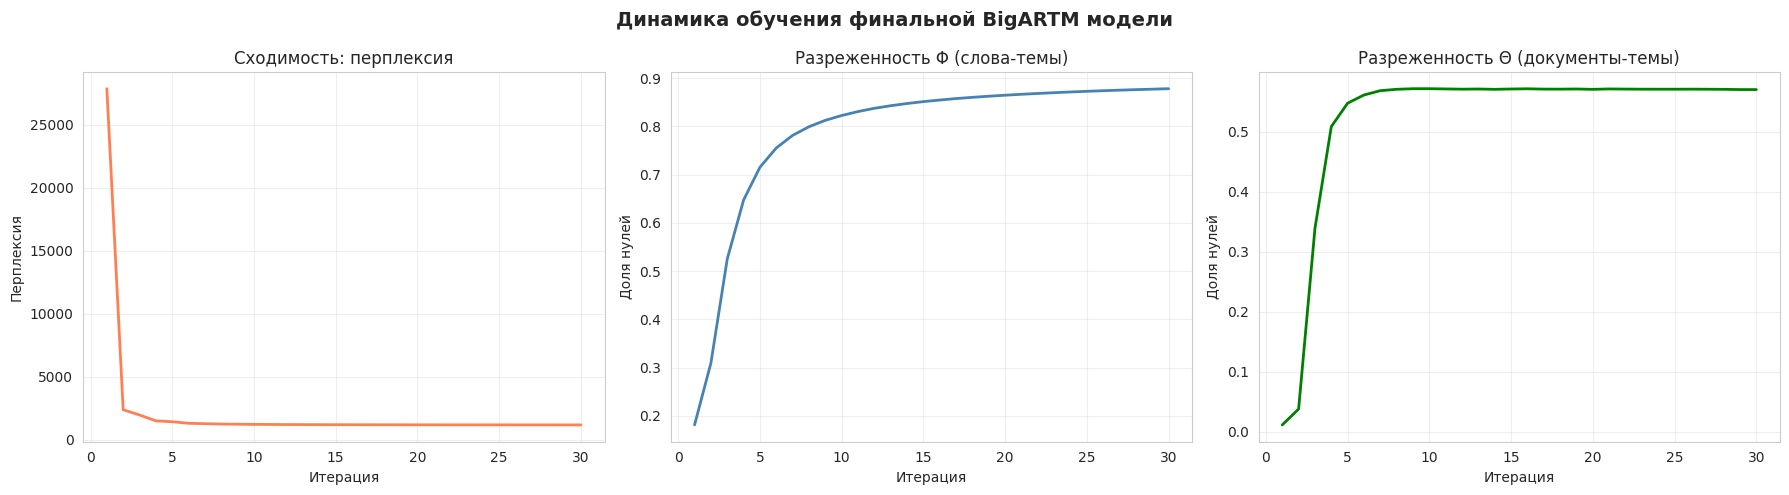

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/bigartm_training_curves.png


In [13]:
perplexity_curve = final_model.score_tracker["PerplexityScore"].value
sparsity_phi_curve   = final_model.score_tracker["SparsityPhiScore"].value
sparsity_theta_curve = final_model.score_tracker["SparsityThetaScore"].value

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
iters = range(1, len(perplexity_curve) + 1)

ax = axes[0]
ax.plot(iters, perplexity_curve, color="coral", linewidth=2)
ax.set_xlabel("Итерация")
ax.set_ylabel("Перплексия")
ax.set_title("Сходимость: перплексия")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(iters, sparsity_phi_curve, color="steelblue", linewidth=2)
ax.set_xlabel("Итерация")
ax.set_ylabel("Доля нулей")
ax.set_title("Разреженность Φ (слова-темы)")
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(iters, sparsity_theta_curve, color="green", linewidth=2)
ax.set_xlabel("Итерация")
ax.set_ylabel("Доля нулей")
ax.set_title("Разреженность Θ (документы-темы)")
ax.grid(True, alpha=0.3)

plt.suptitle("Динамика обучения финальной BigARTM модели", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bigartm_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bigartm_training_curves.png")

## 9. Просмотр и визуализация тем

In [14]:
topic_words = get_topic_words(final_model, num_words=10)

print(f"Темы финальной BigARTM модели (num_topics={BEST_NUM_TOPICS}):")
print_topics(final_model, num_words=10)

Темы финальной BigARTM модели (num_topics=30):
  Тема 01: алгебра(0.037) + класс(0.025) + теория(0.023) + кольцо(0.023) + поле(0.019) + элемент(0.014) + конечный(0.014) + простой(0.014) + алгебраич(0.012) + степень(0.011)
  Тема 02: группа(0.218) + подгруппа(0.032) + модуль(0.026) + категория(0.020) + гомоморфизм(0.013) + когомология(0.012) + морфизм(0.011) + функтор(0.011) + пучок(0.011) + изоморфизм(0.010)
  Тема 03: наз(0.048) + нек(0.029) + теория(0.025) + пер(0.023) + англ(0.016) + рой(0.015) + рых(0.015) + напр(0.013) + рого(0.011) + понятие(0.009)
  Тема 04: время(0.042) + модель(0.035) + процесс(0.013) + данных(0.013) + информация(0.011) + информационный(0.011) + анализ(0.009) + исследование(0.008) + технология(0.008) + средство(0.007)
  Тема 05: программа(0.020) + память(0.010) + выполнение(0.009) + операция(0.008) + код(0.008) + приложение(0.008) + программный(0.008) + процессор(0.007) + данных(0.007) + устройство(0.007)
  Тема 06: область(0.058) + ряд(0.041) + комплексный(0.

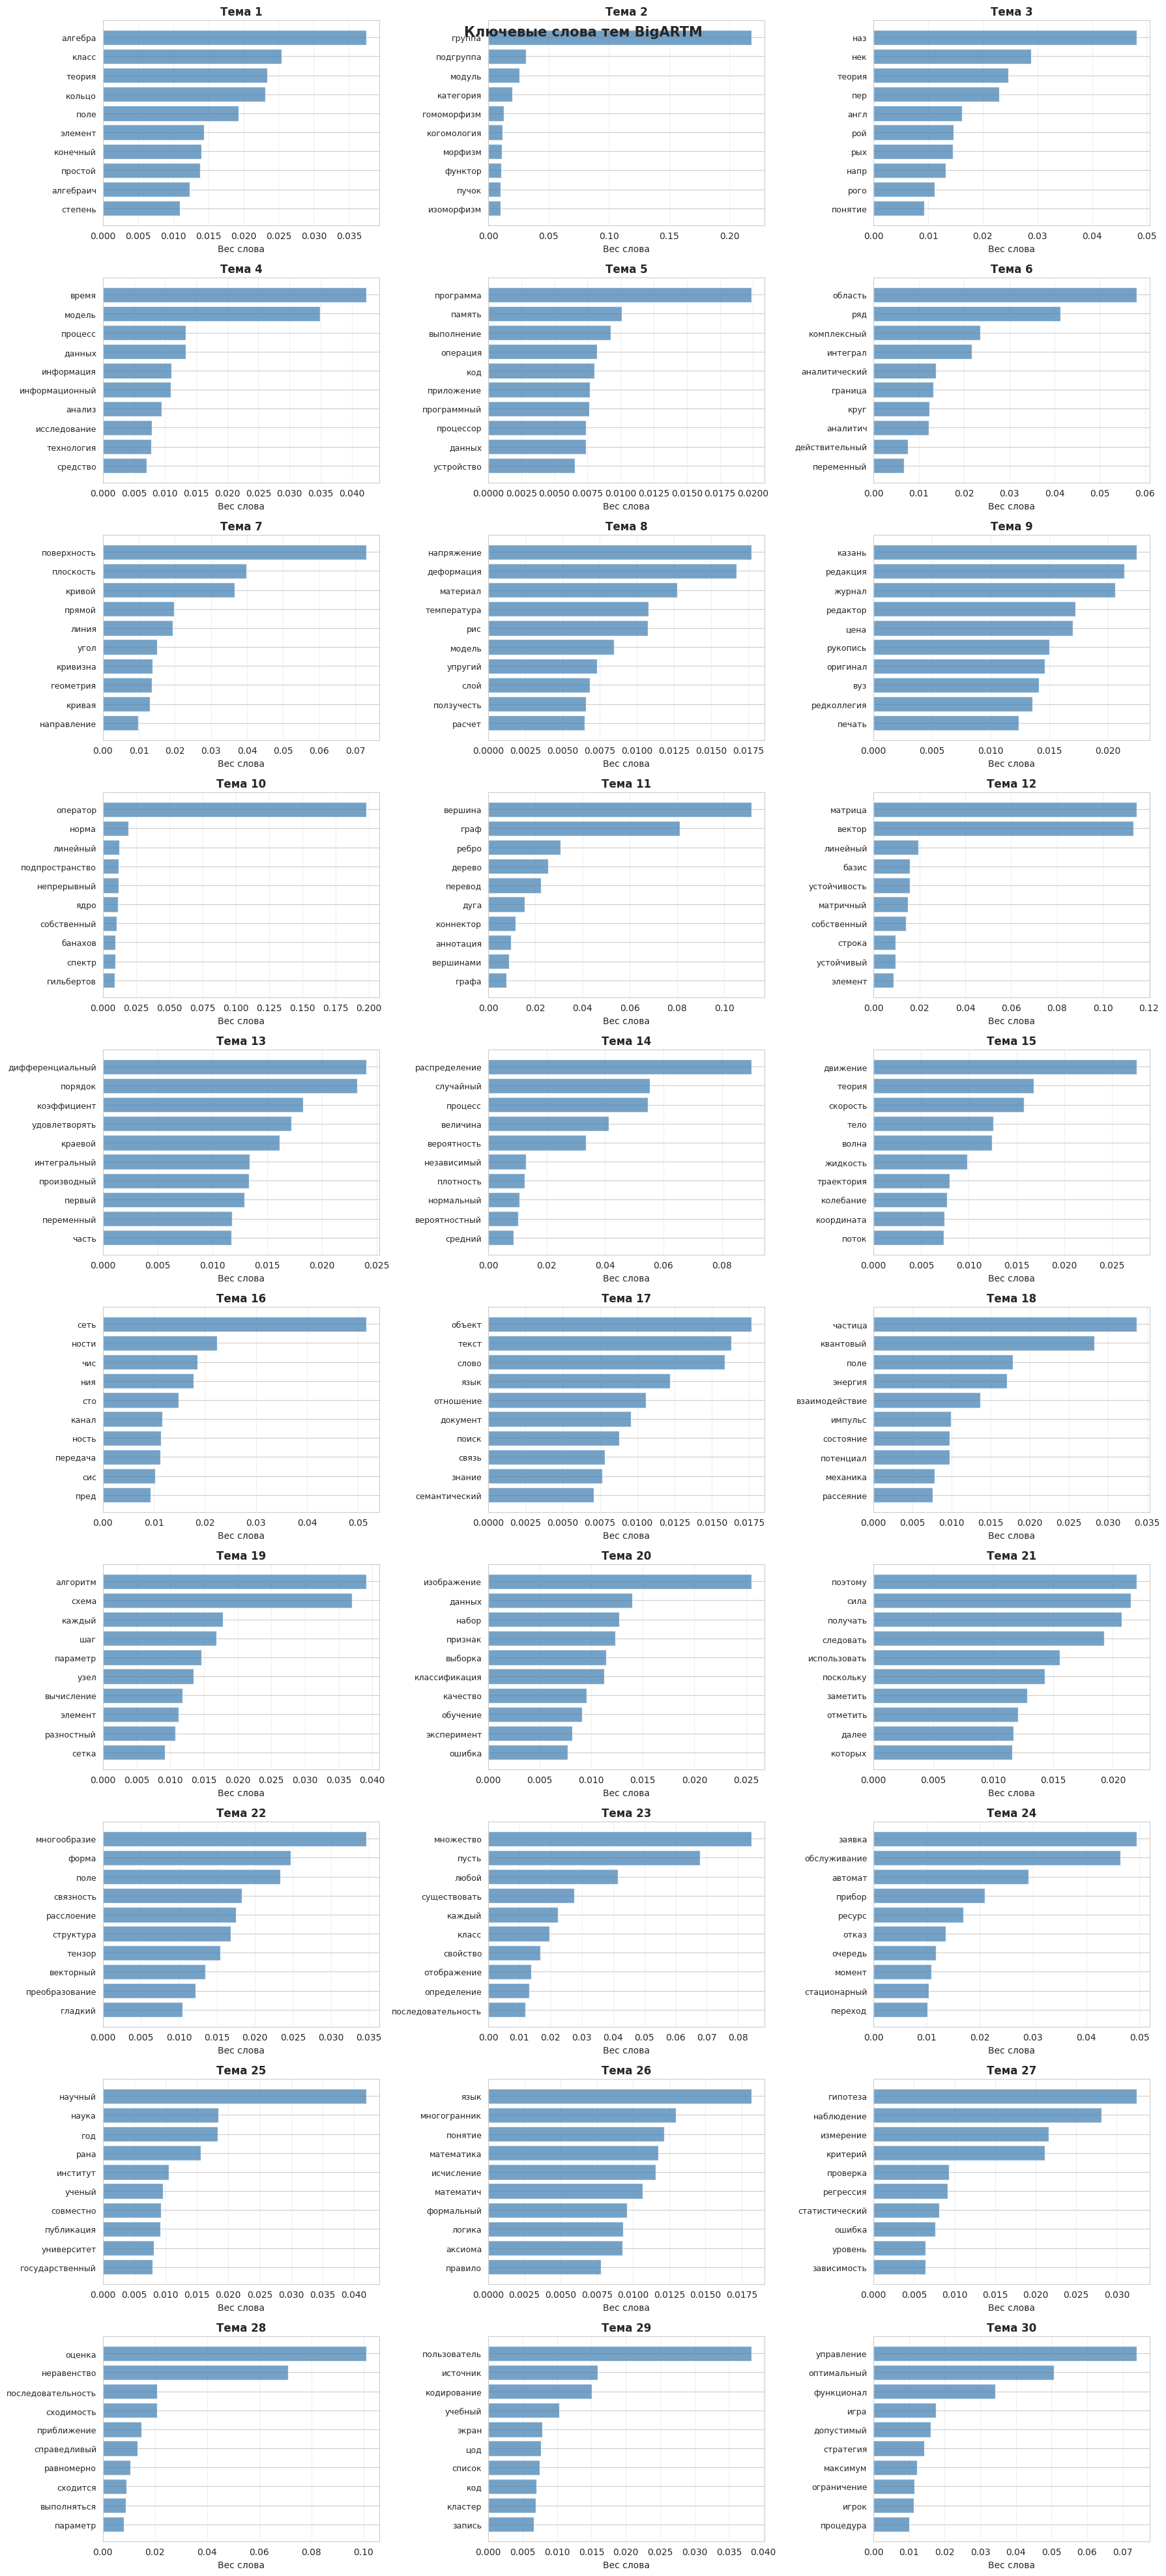

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/bigartm_topics.png


In [15]:
num_topics = BEST_NUM_TOPICS
cols = 3
rows = (num_topics + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, (topic_name, pairs) in enumerate(topic_words.items()):
    if not pairs:
        continue
    words  = [w for w, _ in pairs]
    scores = [s for _, s in pairs]
    ax = axes[i]
    ax.barh(range(len(words)), scores, color="steelblue", alpha=0.75)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Вес слова")
    ax.set_title(f"Тема {i + 1}", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

for j in range(num_topics, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Ключевые слова тем BigARTM", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bigartm_topics.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bigartm_topics.png")

## 10. Матрица Φ и тепловая карта схожести тем

Форма матрицы Φ: (28688, 30)  (слов × тем)


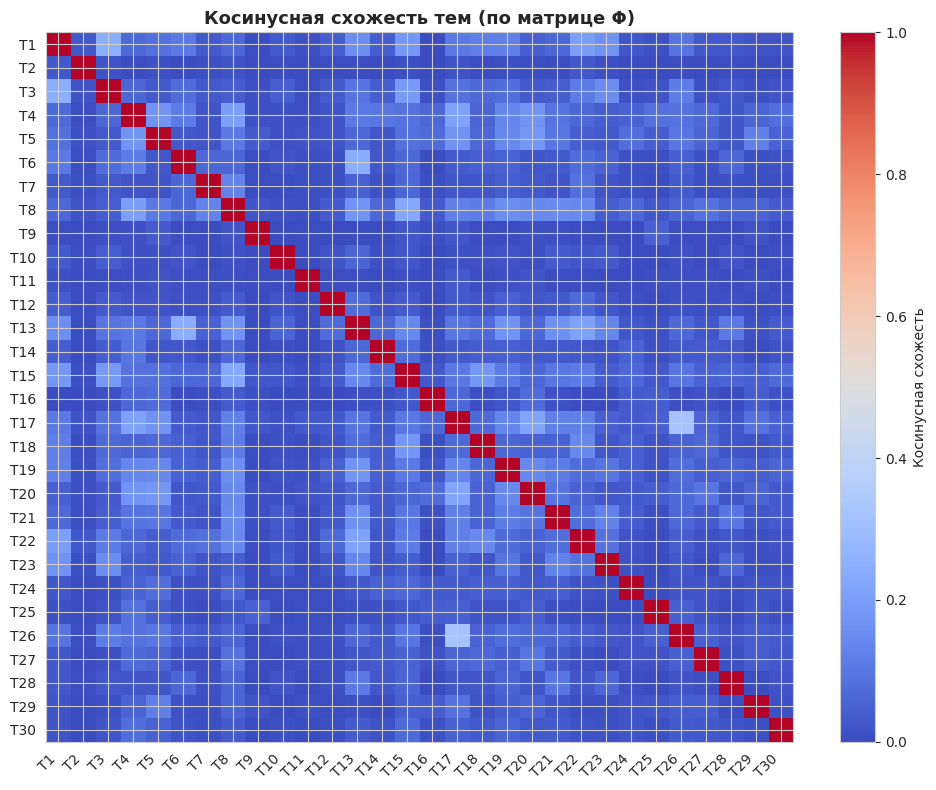

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/bigartm_topic_similarity.png


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Матрица Φ: строки - слова, столбцы - темы
phi = final_model.get_phi()
print(f"Форма матрицы Φ: {phi.shape}  (слов × тем)")

# Косинусная схожесть между темами (по колонкам Φ)
phi_T = phi.values.T # темы × слова
sim_matrix = cosine_similarity(phi_T)

fig, ax = plt.subplots(figsize=(10, 8))
topic_labels = [f"Т{i+1}" for i in range(num_topics)]
im = ax.imshow(sim_matrix, cmap="coolwarm", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(num_topics))
ax.set_yticks(range(num_topics))
ax.set_xticklabels(topic_labels, rotation=45, ha="right")
ax.set_yticklabels(topic_labels)
ax.set_title("Косинусная схожесть тем (по матрице Φ)", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, label="Косинусная схожесть")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bigartm_topic_similarity.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bigartm_topic_similarity.png")

## 11. Матрица Θ: распределение тем по документам

Форма матрицы Θ: (30, 6385)  (тем × документов)


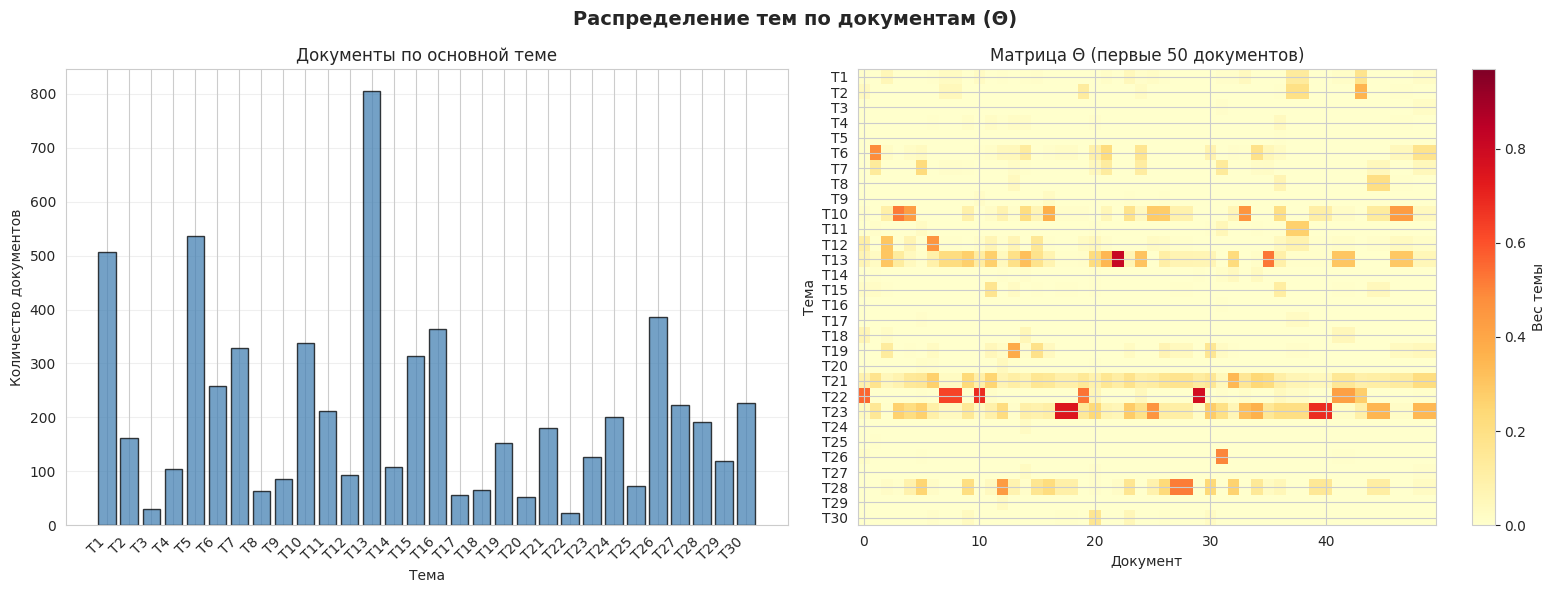

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/bigartm_theta.png


In [ ]:
# Матрица Θ: строки - темы, столбцы - документы
theta = final_model.get_theta()
print(f"Форма матрицы Θ: {theta.shape}  (тем × документов)")

# Основная тема каждого документа
dominant_topics = theta.idxmax(axis=0) # для каждого документа - имя темы
topic_doc_counts = dominant_topics.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма распределения документов
ax = axes[0]
ax.bar(range(len(topic_doc_counts)), topic_doc_counts.values,
       color="steelblue", alpha=0.75, edgecolor="black")
ax.set_xticks(range(len(topic_doc_counts)))
ax.set_xticklabels([f"Т{i+1}" for i in range(len(topic_doc_counts))],
                   rotation=45, ha="right")
ax.set_xlabel("Тема")
ax.set_ylabel("Количество документов")
ax.set_title("Документы по основной теме")
ax.grid(axis="y", alpha=0.3)

# Тепловая карта первых 50 документов
ax = axes[1]
show_docs = min(50, theta.shape[1])
im = ax.imshow(theta.values[:, :show_docs], cmap="YlOrRd",
               aspect="auto", vmin=0, vmax=theta.values.max())
ax.set_xlabel("Документ")
ax.set_ylabel("Тема")
ax.set_yticks(range(num_topics))
ax.set_yticklabels([f"Т{i+1}" for i in range(num_topics)])
ax.set_title(f"Матрица Θ (первые {show_docs} документов)")
plt.colorbar(im, ax=ax, label="Вес темы")

plt.suptitle("Распределение тем по документам (Θ)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bigartm_theta.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bigartm_theta.png")

## 12. Итоговые метрики качества

In [18]:
from gensim.models import CoherenceModel
from gensim import corpora as gensim_corpora

final_topic_words = get_topic_words(final_model, num_words=10)

# c_v
topic_words_list = [
    [w for w, _ in pairs[:10]] for pairs in final_topic_words.values() if pairs
]
all_tokens = [t for doc in texts for t in doc]
tmp_dict = gensim_corpora.Dictionary([all_tokens])

coherence_cv = CoherenceModel(
    topics=topic_words_list, texts=texts,
    dictionary=tmp_dict, coherence="c_v"
).get_coherence()

coherence_umass = CoherenceModel(
    topics=topic_words_list, texts=texts,
    dictionary=tmp_dict, coherence="u_mass"
).get_coherence()

perplexity     = final_model.score_tracker["PerplexityScore"].last_value
sparsity_phi   = final_model.score_tracker["SparsityPhiScore"].last_value
sparsity_theta = final_model.score_tracker["SparsityThetaScore"].last_value

print("=" * 45)
print("Метрики финальной BigARTM модели")
print("=" * 45)
print(f"  Когерентность c_v:         {coherence_cv:.4f}")
print(f"  Когерентность u_mass:      {coherence_umass:.4f}")
print(f"  Перплексия:                {perplexity:.2f}")
print(f"  Разреженность Φ:           {sparsity_phi:.4f}")
print(f"  Разреженность Θ:           {sparsity_theta:.4f}")
print(f"  Число тем:                 {BEST_NUM_TOPICS}")
print(f"  τ SparsePhi:               {FINAL_TAU_PHI}")
print(f"  τ SparseTheta:             {FINAL_TAU_THETA}")
print(f"  τ Декорреляция:            {FINAL_TAU_DECORR}")

pd.DataFrame([{
    "model":           "BigARTM",
    "num_topics":      BEST_NUM_TOPICS,
    "coherence_cv":    coherence_cv,
    "coherence_umass": coherence_umass,
    "perplexity":      perplexity,
    "sparsity_phi":    sparsity_phi,
    "sparsity_theta":  sparsity_theta,
    "tau_phi":         FINAL_TAU_PHI,
    "tau_theta":       FINAL_TAU_THETA,
    "tau_decorr":      FINAL_TAU_DECORR,
}]).to_csv(OUTPUT_DIR / "bigartm_final_metrics.csv", index=False)
print("Метрики сохранены:", OUTPUT_DIR / "bigartm_final_metrics.csv")

Метрики финальной BigARTM модели
  Когерентность c_v:         0.6798
  Когерентность u_mass:      -1.4174
  Перплексия:                1190.64
  Разреженность Φ:           0.8783
  Разреженность Θ:           0.5702
  Число тем:                 30
  τ SparsePhi:               -0.05
  τ SparseTheta:             -0.2
  τ Декорреляция:            1000000.0
Метрики сохранены: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/outputs/bigartm_final_metrics.csv


## 13. Сводный отчёт

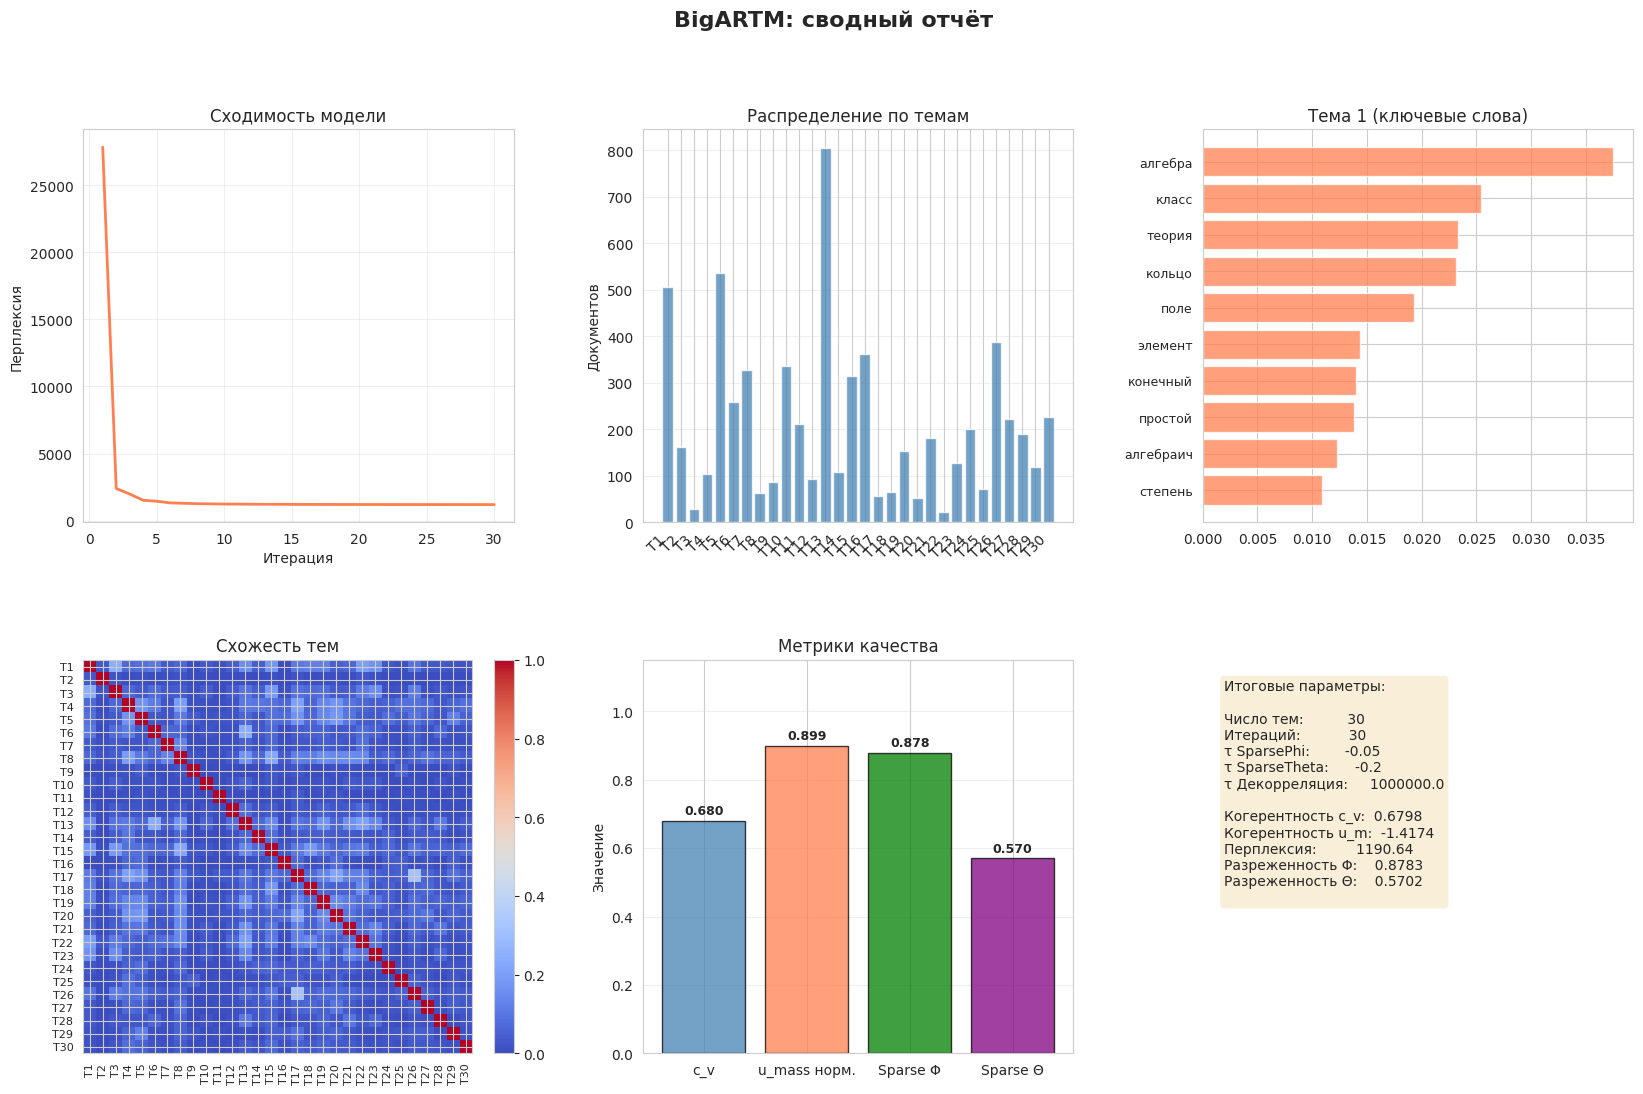

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/figures/bigartm_summary_report.png


In [ ]:
fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# Динамика перплексии
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(1, len(perplexity_curve) + 1), perplexity_curve,
         color="coral", linewidth=2)
ax1.set_xlabel("Итерация")
ax1.set_ylabel("Перплексия")
ax1.set_title("Сходимость модели")
ax1.grid(True, alpha=0.3)

# Распределение документов по темам
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(range(len(topic_doc_counts)), topic_doc_counts.values,
        color="steelblue", alpha=0.75)
ax2.set_xticks(range(len(topic_doc_counts)))
ax2.set_xticklabels([f"Т{i+1}" for i in range(len(topic_doc_counts))],
                    rotation=45, ha="right")
ax2.set_ylabel("Документов")
ax2.set_title("Распределение по темам")
ax2.grid(axis="y", alpha=0.3)

# Слова первой темы
ax3 = fig.add_subplot(gs[0, 2])
first_topic = list(final_topic_words.values())[0]
words  = [w for w, _ in first_topic]
scores = [s for _, s in first_topic]
ax3.barh(range(len(words)), scores, color="coral", alpha=0.75)
ax3.set_yticks(range(len(words)))
ax3.set_yticklabels(words, fontsize=9)
ax3.invert_yaxis()
ax3.set_title("Тема 1 (ключевые слова)")

# Тепловая карта схожести тем
ax4 = fig.add_subplot(gs[1, 0])
im = ax4.imshow(sim_matrix, cmap="coolwarm", vmin=0, vmax=1, aspect="auto")
ax4.set_xticks(range(num_topics))
ax4.set_yticks(range(num_topics))
ax4.set_xticklabels([f"Т{i+1}" for i in range(num_topics)], rotation=90, fontsize=8)
ax4.set_yticklabels([f"Т{i+1}" for i in range(num_topics)], fontsize=8)
ax4.set_title("Схожесть тем")
plt.colorbar(im, ax=ax4, fraction=0.046)

# Метрики: bar chart
ax5 = fig.add_subplot(gs[1, 1])
metrics_names  = ["c_v", "u_mass норм.", "Sparse Φ", "Sparse Θ"]
# u_mass обычно отрицателен - нормируется для визуализации
umass_norm = max(0, (coherence_umass + 14) / 14) # сдвиг в [0,1]
metrics_values = [coherence_cv, umass_norm, sparsity_phi, sparsity_theta]
bars = ax5.bar(metrics_names, metrics_values,
               color=["steelblue", "coral", "green", "purple"],
               alpha=0.75, edgecolor="black")
for bar, val in zip(bars, metrics_values):
    ax5.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01, f"{val:.3f}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax5.set_ylim(0, 1.15)
ax5.set_ylabel("Значение")
ax5.set_title("Метрики качества")
ax5.grid(axis="y", alpha=0.3)

# Текстовая сводка
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
summary = (
    f"Итоговые параметры:\n\n"
    f"Число тем:          {BEST_NUM_TOPICS}\n"
    f"Итераций:           {NUM_PASSES_FINAL_MODEL}\n"
    f"τ SparsePhi:        {FINAL_TAU_PHI}\n"
    f"τ SparseTheta:      {FINAL_TAU_THETA}\n"
    f"τ Декорреляция:     {FINAL_TAU_DECORR}\n\n"
    f"Когерентность c_v:  {coherence_cv:.4f}\n"
    f"Когерентность u_m:  {coherence_umass:.4f}\n"
    f"Перплексия:         {perplexity:.2f}\n"
    f"Разреженность Φ:    {sparsity_phi:.4f}\n"
    f"Разреженность Θ:    {sparsity_theta:.4f}\n"
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes, fontsize=10,
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("BigARTM: сводный отчёт", fontsize=16, fontweight="bold")
plt.savefig(FIGURES_DIR / "bigartm_summary_report.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bigartm_summary_report.png")

## 14. Сохранение документов с метками тем

In [ ]:
# Добавление доминирующей темы и весов всех тем к датафрейму
theta_T = theta.T.reset_index(drop=True) # документы × темы
theta_T.columns = [f"topic_{i+1}_weight" for i in range(num_topics)]

df_out = df.copy().reset_index(drop=True)
df_out["dominant_topic"] = dominant_topics.values[:len(df_out)]
df_out = pd.concat([df_out, theta_T.iloc[:len(df_out)]], axis=1)

save_cols = ["filename", "dominant_topic"] + [c for c in df_out.columns if c.startswith("topic_")]
df_out[save_cols].to_csv(OUTPUT_DIR / "bigartm_documents_topics.csv", index=False, encoding="utf-8")

print("Сохранено:", OUTPUT_DIR / "bigartm_documents_topics.csv")
print("\nПример:")
print(df_out[save_cols].head())

Сохранено: /mnt/c/Users/anmrt/Desktop/Useful shit/Диплом/graduation_thesis/outputs/bigartm_documents_topics.csv

Пример:
         filename dominant_topic  topic_1_weight  topic_2_weight  \
0   00-5-2001.tex       topic_21        0.005606         0.03675   
1        00-5.TEX        topic_5        0.000000         0.00000   
2   00-7-2003.tex       topic_12        0.055061         0.00000   
3        00-7.TEX        topic_9        0.000000         0.00000   
4  01-01-2000.tex        topic_9        0.000000         0.00000   

   topic_3_weight  topic_4_weight  topic_5_weight  topic_6_weight  \
0        0.000000             0.0             0.0        0.000000   
1        0.000000             0.0             0.0        0.480725   
2        0.000631             0.0             0.0        0.020247   
3        0.001739             0.0             0.0        0.002636   
4        0.000000             0.0             0.0        0.021812   

   topic_7_weight  topic_8_weight  ...  topic_21_weight